In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('UberDataset.csv')

In [3]:
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [5]:
dataset['PURPOSE'].fillna('Not', inplace = True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\3867269785.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['PURPOSE'].fillna('Not', inplace = True)


In [6]:
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Not
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [7]:
dataset['START_DATE']= pd.to_datetime(dataset['START_DATE'], errors= 'coerce')

In [8]:
dataset['END_DATE']= pd.to_datetime(dataset['END_DATE'], errors= 'coerce')

In [9]:
dataset['time'] = pd.DatetimeIndex(dataset['START_DATE']).hour
dataset['date'] = pd.DatetimeIndex(dataset['START_DATE']).date

In [10]:
#splitting the trips time into categories so that the analysis is more obvios
dataset['day-night'] = pd.cut(x= dataset['time'],
                              bins = [0, 10, 15, 19, 24],
                              labels = ['Morning', "Afternoon", 'Evening', "Night"])

In [11]:
dataset.dropna(inplace=True)
dataset.drop_duplicates(inplace=True)

## Visualization

In [12]:
#checking the unique values in dataset of the columns with object datatype

obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)        # .index --> to return their names

unique_values = {}
for col in object_cols:
    unique_values[col] = dataset[col].unique().size
unique_values

{'CATEGORY': 2, 'START': 108, 'STOP': 112, 'PURPOSE': 7, 'date': 113}

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\2714989606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(dataset['CATEGORY'],palette="vlag")
C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\2714989606.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(dataset['PURPOSE'], palette="icefire")


(array([  0.,  25.,  50.,  75., 100., 125., 150., 175.]),
 [Text(0.0, 0, '0'),
  Text(25.0, 0, '25'),
  Text(50.0, 0, '50'),
  Text(75.0, 0, '75'),
  Text(100.0, 0, '100'),
  Text(125.0, 0, '125'),
  Text(150.0, 0, '150'),
  Text(175.0, 0, '175')])

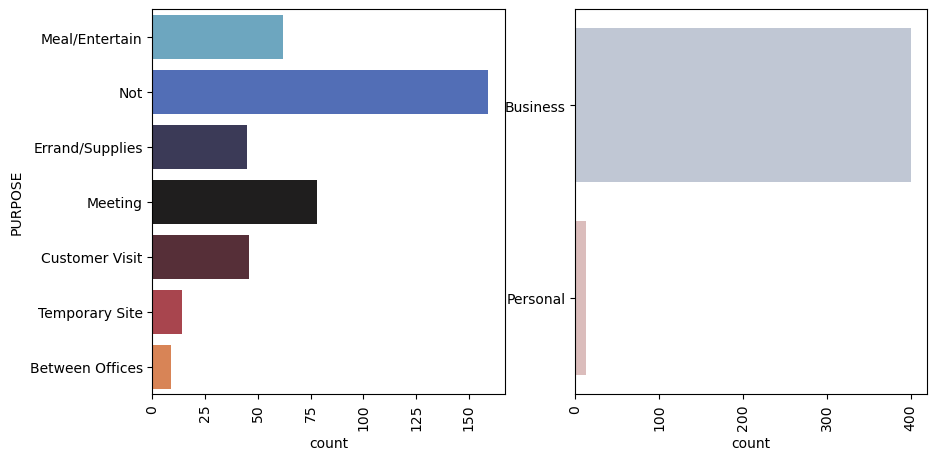

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
sns.countplot(dataset['CATEGORY'],palette="vlag")
plt.xticks(rotation= 90)

plt.subplot(1,2,1)
sns.countplot(dataset['PURPOSE'], palette="icefire")
plt.xticks(rotation= 90)

people use uber for business way more often than they do for personal things. mostly to attend a meeting or a costumer visit

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\507899086.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(dataset['day-night'], palette="vlag")


(array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140'),
  Text(160.0, 0, '160')])

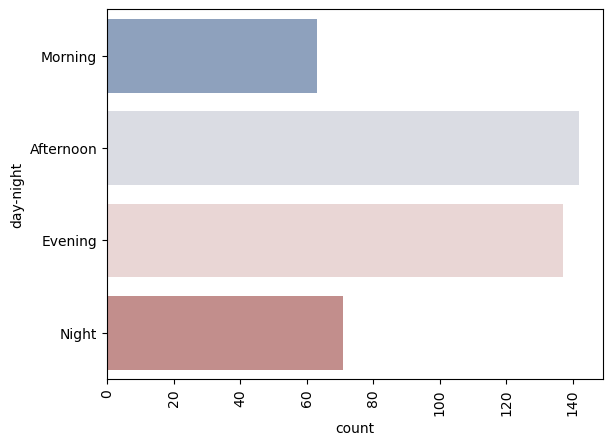

In [14]:
sns.countplot(dataset['day-night'], palette="vlag")
plt.xticks(rotation=90)

trips are most around the afternoon and evening period

In [15]:
from sklearn.preprocessing import OneHotEncoder
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(dataset[object_cols]))
OH_cols.index = dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = dataset.drop(object_cols, axis=1)
dataset = pd.concat([df_final, OH_cols], axis=1)

# This code is modified by Susobhan Akhuli

<Axes: >

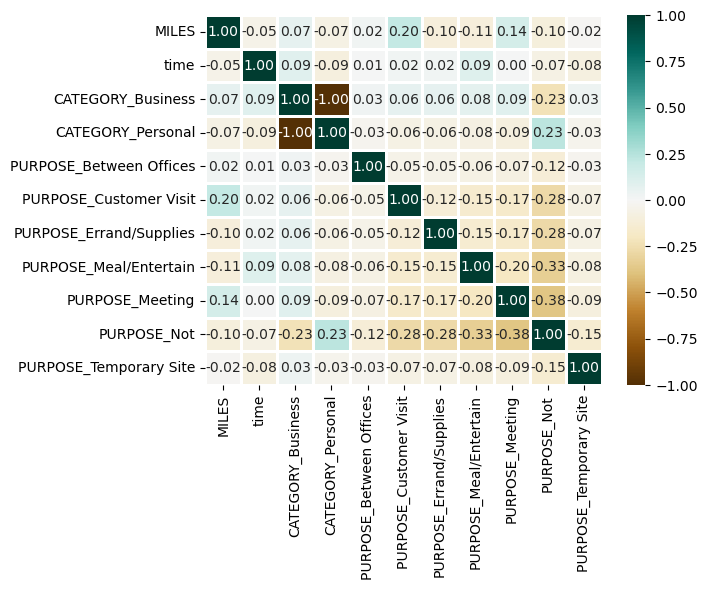

In [16]:
# Select only numerical columns for correlation calculation
numeric_dataset = dataset.select_dtypes(include=['number'])

sns.heatmap(numeric_dataset.corr(), 
            cmap='BrBG', 
            fmt='.2f', 
            linewidths=2, 
            annot=True)

# This code is modified by Susobhan Akhuli

<Axes: >

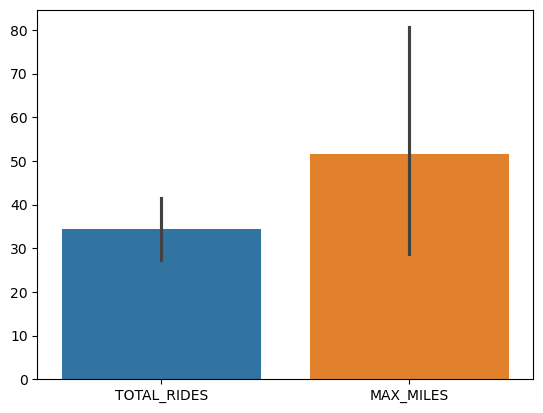

In [21]:
dataset['MONTH'] = pd.to_datetime(dataset['START_DATE']).dt.month
month_label = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'April', 5: 'May', 6: 'June', 
               7: 'July', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
dataset["MONTH"] = dataset["MONTH"].map(month_label)

month_order = ['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 
               'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df = dataset.groupby('MONTH')['MILES'].agg(
    TOTAL_RIDES='count', 
    MAX_MILES='max'
).reindex(month_order)

sns.barplot(data=df)

<Axes: xlabel='MONTH'>

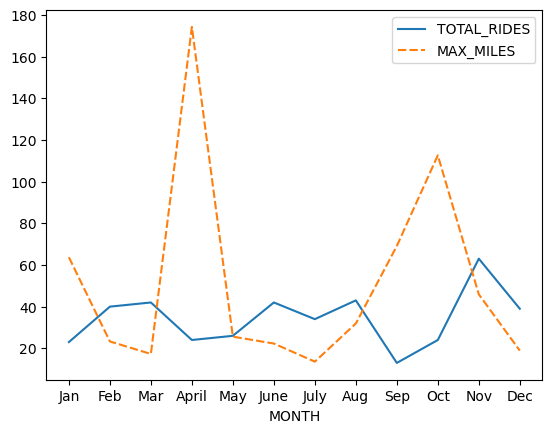

In [33]:
sns.lineplot(data=df)

Rides are at there lowest point in July, March and December- on the other hand, rides are in their longest range in April and October. This may have  to do with holiday seasons or sth.

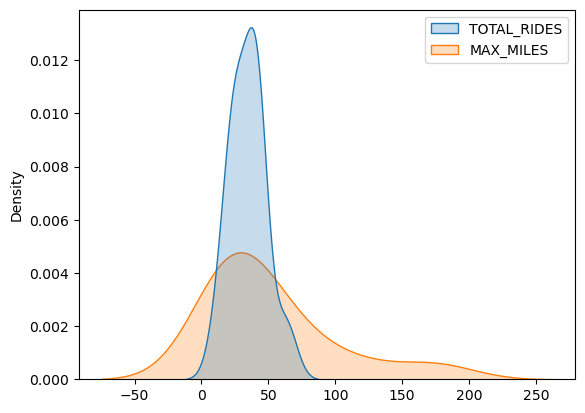

In [34]:
sns.kdeplot(df, fill= True);

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\3698450463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_label.index, y=day_label, palette="vlag");


Text(0, 0.5, 'COUNT')

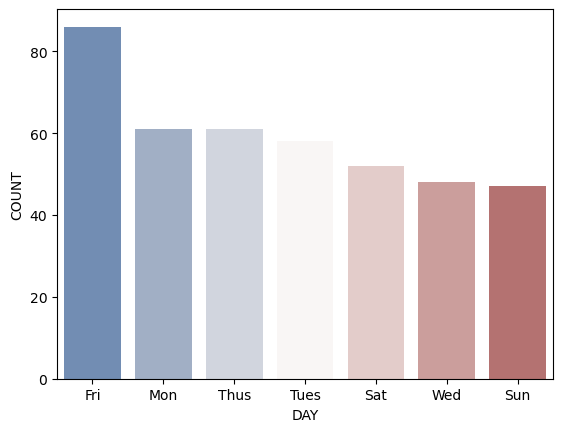

In [23]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)

day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label, palette="vlag");
plt.xlabel('DAY')
plt.ylabel('COUNT')

Friday is the peak of the week, Sunday is the lowest point.

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\1254394273.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(dataset['MILES'], palette="icefire")


<Axes: ylabel='MILES'>

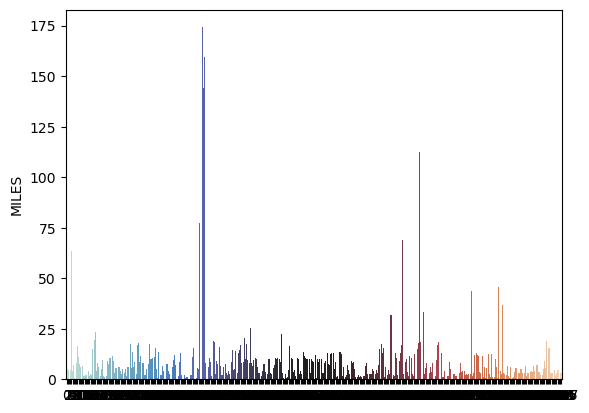

In [24]:
sns.barplot(dataset['MILES'], palette="icefire")

<Axes: ylabel='MILES'>

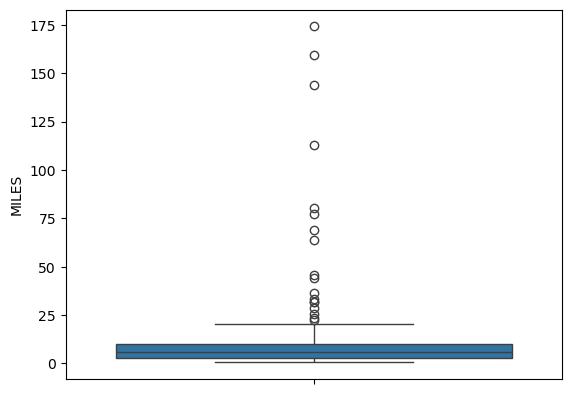

In [26]:
sns.boxplot(dataset['MILES'])

So in the most generality rides vary between a couple of miles and 25 miles, the longest ride on the records was 175 miles, so in general there aren't usually super long rides.

C:\Users\Admin\AppData\Local\Temp\ipykernel_1628\3498805736.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(dataset[dataset['MILES']<40]['MILES'], palette="icefire")


<Axes: xlabel='MILES', ylabel='Density'>

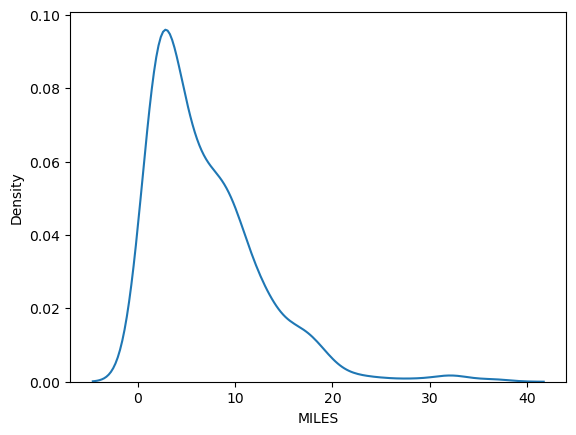

In [31]:
sns.kdeplot(dataset[dataset['MILES']<40]['MILES'], palette="icefire")

Most Rides are below 10 miles, Uber doesn't seem to be used for long rides.
